# Cross-Ticker Analysis

Aggregate results across all 8 tickers:  
AAPL, GOOGL, NVDA, TSLA, F, XOM, CVX, VIX

**Models:** MLP, MLP-log, MLP-log-arb, Conv, Conv-log, Conv-log-arb, Heston

**Sections:**
1. Load all per-ticker metrics
2. Overall MAE/RMSE ranking
3. Per-ticker best model
4. Architecture comparison (MLP vs Conv)
5. Effect of log-transform
6. Effect of arb-penalty
7. Heston vs VAE summary
8. VIX special analysis
9. Arbitrage violations cross-ticker
10. Summary table for thesis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from collections import OrderedDict

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)

ROOT = Path("../..")
TICKERS = ["AAPL", "GOOGL", "NVDA", "TSLA", "F", "XOM", "CVX", "VIX"]
VARIANTS = ["mlp", "mlp_log", "mlp_log_arb", "conv", "conv_log", "conv_log_arb"]
VARIANT_LABELS = {
    "mlp": "MLP", "mlp_log": "MLP-log", "mlp_log_arb": "MLP-log-arb",
    "conv": "Conv", "conv_log": "Conv-log", "conv_log_arb": "Conv-log-arb",
}
MODEL_NAMES = list(VARIANT_LABELS.values()) + ["Heston"]
COLOURS = {
    "MLP": "#1f77b4", "MLP-log": "#9467bd", "MLP-log-arb": "#d62728",
    "Conv": "#2ca02c", "Conv-log": "#8c564b", "Conv-log-arb": "#e377c2",
    "Heston": "#ff7f0e",
}

OUT = ROOT / "artifacts" / "comparison" / "cross_ticker"
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)
print(f"Output → {OUT.resolve()}")

Output → C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\comparison\cross_ticker


## §1 Load Per-Ticker Eval Metrics

In [2]:
# Load test_metrics.json for each (ticker, variant)
rows = []
for ticker in TICKERS:
    for variant, label in VARIANT_LABELS.items():
        path = ROOT / "artifacts" / "eval" / ticker / variant / "test_metrics.json"
        if not path.exists():
            print(f"⚠ Missing: {path}")
            continue
        with open(path) as f:
            m = json.load(f)
        rows.append({
            "Ticker": ticker,
            "Model": label,
            "MAE (vp)": m.get("mae_original", m.get("mae_vol_points", None)),
            "RMSE (vp)": m.get("rmse_original", None),
        })
        # Fix units: if stored as fraction (0.01), convert to vol points (1.0)
        if rows[-1]["MAE (vp)"] is not None and rows[-1]["MAE (vp)"] < 0.5:
            rows[-1]["MAE (vp)"] *= 100
        if rows[-1]["RMSE (vp)"] is not None and rows[-1]["RMSE (vp)"] < 0.5:
            rows[-1]["RMSE (vp)"] *= 100

# Load Heston metrics from validation tables if available
for ticker in TICKERS:
    val_path = ROOT / "artifacts" / "validation" / ticker / "tables" / "error_distribution_stats.csv"
    if val_path.exists():
        df = pd.read_csv(val_path, index_col=0)
        if "Heston" in df.index:
            rows.append({
                "Ticker": ticker,
                "Model": "Heston",
                "MAE (vp)": None,  # Will compute from surfaces
                "RMSE (vp)": None,
            })

metrics_df = pd.DataFrame(rows)
print(f"Loaded {len(rows)} (ticker, model) metrics")
display(metrics_df.head(10))

Loaded 56 (ticker, model) metrics


,Ticker,Model,MAE (vp),RMSE (vp)
0,AAPL,MLP,1.138675,1.640742
1,AAPL,MLP-log,1.087494,1.716128
2,AAPL,MLP-log-arb,1.116725,1.650702
3,AAPL,Conv,1.115611,1.619505
4,AAPL,Conv-log,1.146141,1.762520
5,AAPL,Conv-log-arb,1.244689,1.756550
6,GOOGL,MLP,1.398458,2.006770
7,GOOGL,MLP-log,1.382369,2.113199
8,GOOGL,MLP-log-arb,1.404946,2.124319
9,GOOGL,Conv,1.407073,2.045487


In [3]:
# Also load full surfaces to compute Heston MAE where validation tables aren't ready
heston_metrics = []
for ticker in TICKERS:
    heston_path = ROOT / "data" / "processed" / "heston" / "surfaces" / f"{ticker}_heston_surfaces.npy"
    heston_dates_path = ROOT / "data" / "processed" / "heston" / "surfaces" / f"{ticker}_heston_surface_dates.csv"
    if not heston_path.exists():
        continue

    # Get market reference from first VAE variant
    market_path = ROOT / "artifacts" / "eval" / ticker / "mlp" / "surfaces" / "market_surfaces.npy"
    vae_dates_path = ROOT / "artifacts" / "eval" / ticker / "mlp" / "surfaces" / "vae_surface_dates.csv"
    if not market_path.exists():
        continue

    heston_surf = np.load(heston_path)
    heston_dates = pd.to_datetime(pd.read_csv(heston_dates_path)["date"])
    market_surf = np.load(market_path)
    vae_dates = pd.to_datetime(pd.read_csv(vae_dates_path)["date"])

    # Align dates
    common = set(heston_dates.dt.date) & set(vae_dates.dt.date)
    h_mask = [d in common for d in heston_dates.dt.date]
    v_mask = [d in common for d in vae_dates.dt.date]
    h_aligned = heston_surf[h_mask]
    m_aligned = market_surf[v_mask]

    valid = np.isfinite(h_aligned) & np.isfinite(m_aligned)
    if valid.sum() == 0:
        continue
    ae = np.abs(h_aligned[valid] - m_aligned[valid])
    heston_metrics.append({
        "Ticker": ticker,
        "Model": "Heston",
        "MAE (vp)": ae.mean() * 100,
        "RMSE (vp)": np.sqrt(((h_aligned[valid] - m_aligned[valid])**2).mean()) * 100,
        "N_dates": len(common),
    })
    print(f"{ticker} Heston: MAE={ae.mean()*100:.2f} vp, RMSE={np.sqrt(((h_aligned[valid]-m_aligned[valid])**2).mean())*100:.2f} vp ({len(common)} dates)")

heston_df = pd.DataFrame(heston_metrics)

# Merge Heston metrics into main df
if len(heston_df) > 0:
    # Remove placeholder Heston rows and add real ones
    metrics_df = metrics_df[metrics_df["Model"] != "Heston"]
    metrics_df = pd.concat([metrics_df, heston_df[["Ticker", "Model", "MAE (vp)", "RMSE (vp)"]]], ignore_index=True)

print(f"\nTotal: {len(metrics_df)} (ticker, model) combinations")

AAPL Heston: MAE=1.28 vp, RMSE=2.19 vp (244 dates)
GOOGL Heston: MAE=1.43 vp, RMSE=2.43 vp (244 dates)
NVDA Heston: MAE=1.64 vp, RMSE=3.10 vp (244 dates)
TSLA Heston: MAE=1.58 vp, RMSE=2.73 vp (244 dates)
F Heston: MAE=8.16 vp, RMSE=17.13 vp (244 dates)
XOM Heston: MAE=1.57 vp, RMSE=2.92 vp (244 dates)
CVX Heston: MAE=1.71 vp, RMSE=3.29 vp (244 dates)
VIX Heston: MAE=13.34 vp, RMSE=26.73 vp (244 dates)

Total: 56 (ticker, model) combinations


## §2 Overall MAE / RMSE Ranking

Average across all tickers:


,MAE (vp),RMSE (vp)
Model,,
MLP,3.195,5.177
Conv,3.255,5.246
MLP-log,3.277,6.109
Conv-log,3.280,6.157
Conv-log-arb,3.298,6.215
MLP-log-arb,3.691,7.185
Heston,3.839,7.566


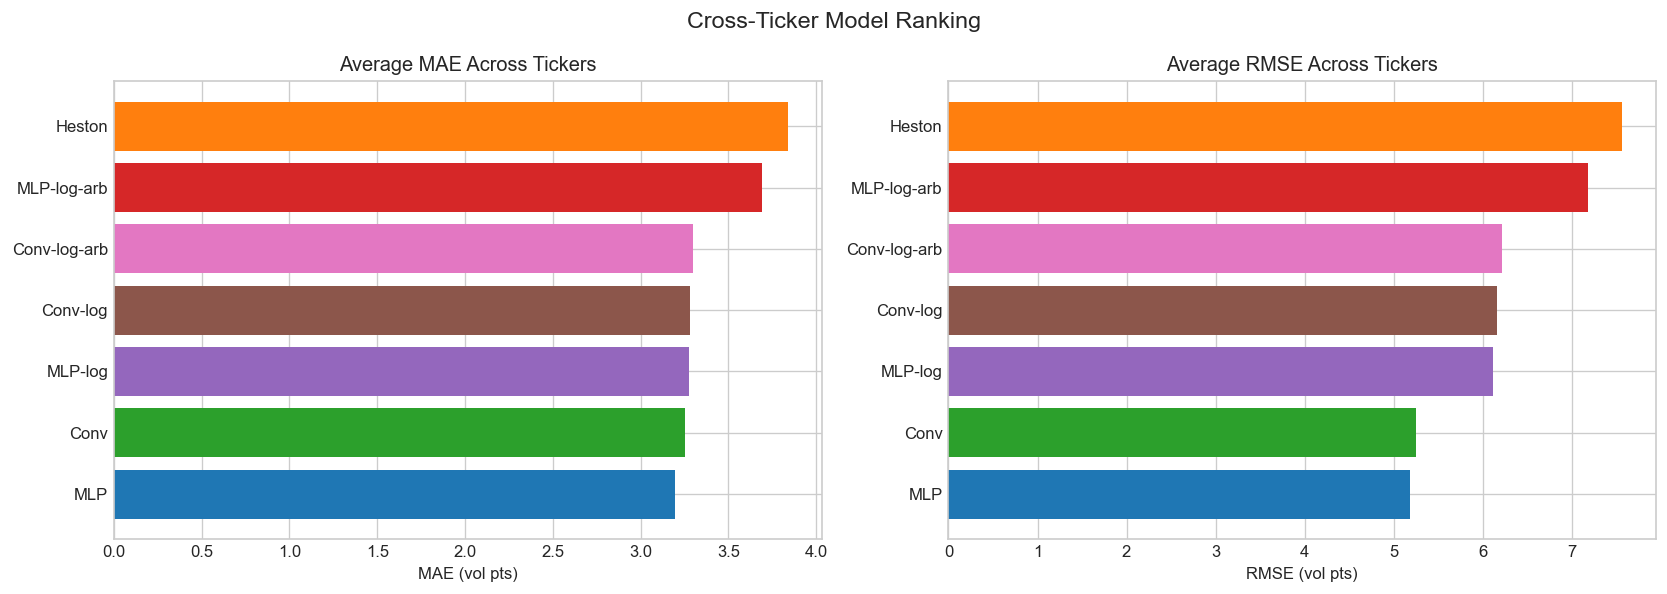

In [4]:
# Average across tickers
avg = metrics_df.groupby("Model")[["MAE (vp)", "RMSE (vp)"]].mean().sort_values("MAE (vp)")
avg.to_csv(OUT / "tables" / "avg_metrics_by_model.csv")
print("Average across all tickers:")
display(avg.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [COLOURS.get(n, "grey") for n in avg.index]
ax1.barh(avg.index, avg["MAE (vp)"], color=colors)
ax1.set_xlabel("MAE (vol pts)")
ax1.set_title("Average MAE Across Tickers")
ax2.barh(avg.index, avg["RMSE (vp)"], color=colors)
ax2.set_xlabel("RMSE (vol pts)")
ax2.set_title("Average RMSE Across Tickers")
fig.suptitle("Cross-Ticker Model Ranking", fontsize=14)
fig.tight_layout()
fig.savefig(OUT / "plots" / "avg_ranking.png", bbox_inches="tight", dpi=150)
plt.show()

## §3 Per-Ticker Best Model

In [5]:
# Pivot: ticker × model
pivot = metrics_df.pivot_table(index="Ticker", columns="Model", values="MAE (vp)")
pivot = pivot[MODEL_NAMES] if all(m in pivot.columns for m in MODEL_NAMES) else pivot

# Bold the minimum per row
best_model = pivot.idxmin(axis=1)
pivot_styled = pivot.style.highlight_min(axis=1, color="lightgreen")

print("MAE (vol points) — per ticker × model:")
display(pivot_styled.format("{:.3f}"))

best_df = best_model.reset_index()
best_df.columns = ["Ticker", "Best Model"]
best_df.to_csv(OUT / "tables" / "best_model_per_ticker.csv", index=False)
display(best_df)

pivot.to_csv(OUT / "tables" / "mae_pivot.csv")

MAE (vol points) — per ticker × model:


Model,MLP,MLP-log,MLP-log-arb,Conv,Conv-log,Conv-log-arb,Heston
Ticker,,,,,,,
AAPL,1.139,1.087,1.117,1.116,1.146,1.245,1.281
CVX,1.788,1.676,1.860,1.733,1.705,1.672,1.714
F,7.779,7.320,7.838,7.685,7.388,7.558,8.164
GOOGL,1.398,1.382,1.405,1.407,1.447,1.409,1.427
NVDA,1.834,1.803,1.962,1.904,1.887,1.901,1.636
TSLA,2.609,3.068,2.986,2.722,2.732,2.672,1.578
VIX,7.123,7.873,10.602,7.479,8.178,8.126,13.340
XOM,1.895,2.003,1.754,1.992,1.757,1.802,1.574


,Ticker,Best Model
0,AAPL,MLP-log
1,CVX,Conv-log-arb
2,F,MLP-log
3,GOOGL,MLP-log
4,NVDA,Heston
5,TSLA,Heston
6,VIX,MLP
7,XOM,Heston


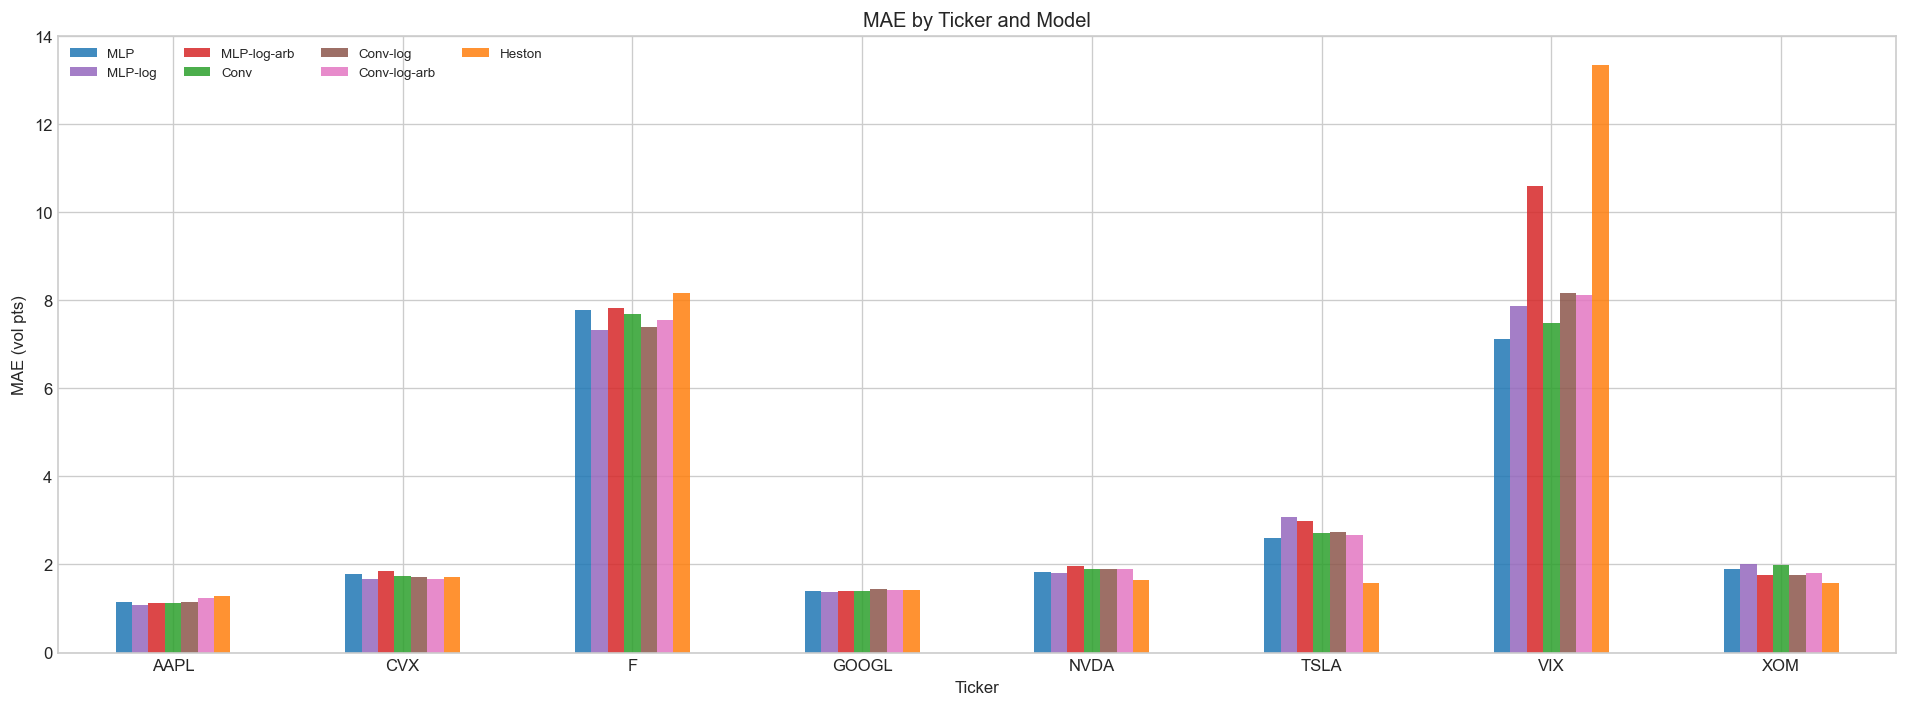

In [6]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(16, 6))
pivot_plot = pivot.reindex(columns=[m for m in MODEL_NAMES if m in pivot.columns])
pivot_plot.plot(kind="bar", ax=ax, color=[COLOURS.get(m, "grey") for m in pivot_plot.columns], alpha=0.85)
ax.set_ylabel("MAE (vol pts)")
ax.set_xlabel("Ticker")
ax.set_title("MAE by Ticker and Model")
ax.legend(fontsize=8, ncol=4)
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mae_by_ticker.png", bbox_inches="tight", dpi=150)
plt.show()

## §4 Architecture Comparison (MLP vs Conv)

In [7]:
# Average MLP variants vs Conv variants
mlp_models = ["MLP", "MLP-log", "MLP-log-arb"]
conv_models = ["Conv", "Conv-log", "Conv-log-arb"]

arch_rows = []
for ticker in TICKERS:
    t_df = metrics_df[metrics_df["Ticker"] == ticker]
    mlp_mae = t_df[t_df["Model"].isin(mlp_models)]["MAE (vp)"].mean()
    conv_mae = t_df[t_df["Model"].isin(conv_models)]["MAE (vp)"].mean()
    arch_rows.append({"Ticker": ticker, "MLP avg": mlp_mae, "Conv avg": conv_mae,
                      "Winner": "MLP" if mlp_mae < conv_mae else "Conv"})

arch_df = pd.DataFrame(arch_rows).set_index("Ticker")
arch_df.to_csv(OUT / "tables" / "arch_comparison.csv")
display(arch_df.round(3))

mlp_wins = (arch_df["Winner"] == "MLP").sum()
conv_wins = (arch_df["Winner"] == "Conv").sum()
print(f"\nMLP wins {mlp_wins}/{len(TICKERS)} tickers, Conv wins {conv_wins}/{len(TICKERS)} tickers")

,MLP avg,Conv avg,Winner
Ticker,,,
AAPL,1.114,1.169,MLP
GOOGL,1.395,1.421,MLP
NVDA,1.866,1.897,MLP
TSLA,2.888,2.709,Conv
F,7.645,7.543,Conv
XOM,1.884,1.850,Conv
CVX,1.774,1.703,Conv
VIX,8.533,7.928,Conv



MLP wins 3/8 tickers, Conv wins 5/8 tickers


## §5 Effect of Log-Transform

In [8]:
log_rows = []
for ticker in TICKERS:
    t_df = metrics_df[metrics_df["Ticker"] == ticker]
    for base, log_var in [("MLP", "MLP-log"), ("Conv", "Conv-log")]:
        raw = t_df[t_df["Model"] == base]["MAE (vp)"].values
        log = t_df[t_df["Model"] == log_var]["MAE (vp)"].values
        if len(raw) == 1 and len(log) == 1:
            log_rows.append({
                "Ticker": ticker, "Arch": base,
                "Raw MAE": raw[0], "Log MAE": log[0],
                "Δ (log − raw)": log[0] - raw[0],
                "Log helps": log[0] < raw[0],
            })

log_df = pd.DataFrame(log_rows)
log_df.to_csv(OUT / "tables" / "log_transform_effect.csv", index=False)
display(log_df.round(3))

helps_pct = 100 * log_df["Log helps"].mean()
print(f"\nLog transform helps in {helps_pct:.0f}% of (ticker, arch) pairs")
print(f"Average Δ: {log_df['Δ (log − raw)'].mean():.3f} vp "
      f"({'log helps' if log_df['Δ (log − raw)'].mean() < 0 else 'raw is better'})")

,Ticker,Arch,Raw MAE,Log MAE,Δ (log − raw),Log helps
0,AAPL,MLP,1.139,1.087,-0.051,True
1,AAPL,Conv,1.116,1.146,0.031,False
2,GOOGL,MLP,1.398,1.382,-0.016,True
3,GOOGL,Conv,1.407,1.447,0.040,False
4,NVDA,MLP,1.834,1.803,-0.031,True
5,NVDA,Conv,1.904,1.887,-0.017,True
6,TSLA,MLP,2.609,3.068,0.459,False
7,TSLA,Conv,2.722,2.732,0.010,False
8,F,MLP,7.779,7.320,-0.459,True
9,F,Conv,7.685,7.388,-0.297,True



Log transform helps in 56% of (ticker, arch) pairs
Average Δ: 0.053 vp (raw is better)


## §6 Effect of Arb-Penalty

In [9]:
arb_rows = []
for ticker in TICKERS:
    t_df = metrics_df[metrics_df["Ticker"] == ticker]
    for base, arb_var in [("MLP-log", "MLP-log-arb"), ("Conv-log", "Conv-log-arb")]:
        base_v = t_df[t_df["Model"] == base]["MAE (vp)"].values
        arb_v = t_df[t_df["Model"] == arb_var]["MAE (vp)"].values
        if len(base_v) == 1 and len(arb_v) == 1:
            arb_rows.append({
                "Ticker": ticker, "Base": base,
                "Base MAE": base_v[0], "Arb MAE": arb_v[0],
                "Δ (arb − base)": arb_v[0] - base_v[0],
                "Accuracy cost": arb_v[0] - base_v[0],
            })

arb_df = pd.DataFrame(arb_rows)
arb_df.to_csv(OUT / "tables" / "arb_penalty_effect.csv", index=False)
display(arb_df.round(3))

print(f"\nAverage accuracy cost of arb penalty: {arb_df['Accuracy cost'].mean():.3f} vp")
print(f"Max accuracy cost: {arb_df['Accuracy cost'].max():.3f} vp")
print(f"Cases where arb penalty improves accuracy: {(arb_df['Accuracy cost'] < 0).sum()}/{len(arb_df)}")

,Ticker,Base,Base MAE,Arb MAE,Δ (arb − base),Accuracy cost
0,AAPL,MLP-log,1.087,1.117,0.029,0.029
1,AAPL,Conv-log,1.146,1.245,0.099,0.099
2,GOOGL,MLP-log,1.382,1.405,0.023,0.023
3,GOOGL,Conv-log,1.447,1.409,-0.037,-0.037
4,NVDA,MLP-log,1.803,1.962,0.159,0.159
5,NVDA,Conv-log,1.887,1.901,0.015,0.015
6,TSLA,MLP-log,3.068,2.986,-0.082,-0.082
7,TSLA,Conv-log,2.732,2.672,-0.059,-0.059
8,F,MLP-log,7.320,7.838,0.518,0.518
9,F,Conv-log,7.388,7.558,0.169,0.169



Average accuracy cost of arb penalty: 0.216 vp
Max accuracy cost: 2.729 vp
Cases where arb penalty improves accuracy: 6/16


## §7 Heston vs VAE Summary

In [10]:
heston_vs = []
for ticker in TICKERS:
    t_df = metrics_df[metrics_df["Ticker"] == ticker]
    heston_row = t_df[t_df["Model"] == "Heston"]
    if len(heston_row) == 0:
        continue
    heston_mae = heston_row["MAE (vp)"].values[0]
    best_vae_row = t_df[t_df["Model"] != "Heston"].sort_values("MAE (vp)").iloc[0]
    worst_vae_row = t_df[t_df["Model"] != "Heston"].sort_values("MAE (vp)").iloc[-1]
    heston_vs.append({
        "Ticker": ticker,
        "Heston MAE": heston_mae,
        "Best VAE": best_vae_row["Model"],
        "Best VAE MAE": best_vae_row["MAE (vp)"],
        "Worst VAE MAE": worst_vae_row["MAE (vp)"],
        "VAE advantage": heston_mae - best_vae_row["MAE (vp)"],
        "Heston beats worst VAE": heston_mae < worst_vae_row["MAE (vp)"],
    })

heston_vs_df = pd.DataFrame(heston_vs).set_index("Ticker")
heston_vs_df.to_csv(OUT / "tables" / "heston_vs_vae.csv")
display(heston_vs_df.round(3))

vae_wins = (heston_vs_df["VAE advantage"] > 0).sum()
print(f"\nBest VAE beats Heston in {vae_wins}/{len(heston_vs_df)} tickers")
print(f"Average VAE advantage: {heston_vs_df['VAE advantage'].mean():.3f} vp")

,Heston MAE,Best VAE,Best VAE MAE,Worst VAE MAE,VAE advantage,Heston beats worst VAE
Ticker,,,,,,
AAPL,1.281,MLP-log,1.087,1.245,0.194,False
GOOGL,1.427,MLP-log,1.382,1.447,0.044,True
NVDA,1.636,MLP-log,1.803,1.962,-0.166,True
TSLA,1.578,MLP,2.609,3.068,-1.031,True
F,8.164,MLP-log,7.320,7.838,0.844,False
XOM,1.574,MLP-log-arb,1.754,2.003,-0.180,True
CVX,1.714,Conv-log-arb,1.672,1.860,0.042,True
VIX,13.340,MLP,7.123,10.602,6.217,False



Best VAE beats Heston in 5/8 tickers
Average VAE advantage: 0.745 vp


## §8 VIX Special Analysis

In [11]:
vix_df = metrics_df[metrics_df["Ticker"] == "VIX"].set_index("Model")
if len(vix_df) > 0:
    print("VIX — All Models:")
    display(vix_df.round(3))

    # Compare VIX vs average of equity tickers
    equity_tickers = [t for t in TICKERS if t != "VIX"]
    equity_avg = metrics_df[metrics_df["Ticker"].isin(equity_tickers)].groupby("Model")["MAE (vp)"].mean()
    vix_vs_equity = pd.DataFrame({
        "VIX MAE": vix_df["MAE (vp)"],
        "Equity avg MAE": equity_avg,
        "Δ (VIX − equity)": vix_df["MAE (vp)"] - equity_avg,
    }).dropna()
    vix_vs_equity.to_csv(OUT / "tables" / "vix_vs_equity.csv")
    print("\nVIX vs Average Equity:")
    display(vix_vs_equity.round(3))

    if "Heston" in vix_df.index:
        heston_vix = vix_df.loc["Heston", "MAE (vp)"]
        best_vae_vix = vix_df.drop("Heston", errors="ignore")["MAE (vp)"].min()
        print(f"\nVIX: Heston MAE = {heston_vix:.2f} vp, Best VAE = {best_vae_vix:.2f} vp")
        print("VIX is mean-reverting (not GBM) — Heston model assumption violation.")
        if heston_vix > best_vae_vix * 1.5:
            print("→ Heston performs notably worse on VIX, supporting thesis that VAEs make no distributional assumptions.")
else:
    print("VIX data not available yet.")

VIX — All Models:


,Ticker,MAE (vp),RMSE (vp)
Model,,,
MLP,VIX,7.123,12.587
MLP-log,VIX,7.873,16.668
MLP-log-arb,VIX,10.602,23.205
Conv,VIX,7.479,12.936
Conv-log,VIX,8.178,17.854
Conv-log-arb,VIX,8.126,17.903
Heston,VIX,13.340,26.725



VIX vs Average Equity:


,VIX MAE,Equity avg MAE,Δ (VIX − equity)
Model,,,
Conv,7.479,2.651,4.827
Conv-log,8.178,2.580,5.598
Conv-log-arb,8.126,2.609,5.518
Heston,13.340,2.482,10.858
MLP,7.123,2.634,4.488
MLP-log,7.873,2.620,5.253
MLP-log-arb,10.602,2.703,7.899



VIX: Heston MAE = 13.34 vp, Best VAE = 7.12 vp
VIX is mean-reverting (not GBM) — Heston model assumption violation.
→ Heston performs notably worse on VIX, supporting thesis that VAEs make no distributional assumptions.


## §9 Arbitrage Violations Cross-Ticker

In [12]:
# Load arb violation tables from validation output
arb_all = []
for ticker in TICKERS:
    arb_path = ROOT / "artifacts" / "validation" / ticker / "tables" / "arbitrage_violations.csv"
    if not arb_path.exists():
        continue
    df = pd.read_csv(arb_path, index_col=0)
    df["Ticker"] = ticker
    arb_all.append(df)

if arb_all:
    arb_combined = pd.concat(arb_all)
    # Butterfly violation rate by model across tickers
    but_pivot = arb_combined.pivot_table(
        index="Ticker", columns=arb_combined.index,
        values="Butterfly %"
    )
    print("Butterfly Violation % by Ticker:")
    display(but_pivot.round(2))
    but_pivot.to_csv(OUT / "tables" / "butterfly_cross_ticker.csv")

    # Average butterfly rate
    avg_but = but_pivot.mean()
    print("\nAverage Butterfly % across tickers:")
    display(avg_but.round(2))
else:
    print("No validation tables found yet. Run validation notebooks first.")

Butterfly Violation % by Ticker:


Surface,Conv,Conv-log,Conv-log-arb,Heston,MLP,MLP-log,MLP-log-arb,Market
Ticker,,,,,,,,
AAPL,23.74,24.33,1.13,0.00,27.45,23.57,5.73,2.48
CVX,29.09,29.06,1.56,0.00,33.79,32.13,3.06,16.77
F,28.45,23.30,1.71,0.95,32.50,30.12,1.93,31.89
GOOGL,19.88,22.19,0.53,0.00,24.48,24.03,1.79,3.48
NVDA,26.71,24.44,1.10,0.20,25.91,30.32,2.13,6.66
TSLA,23.48,19.11,0.17,0.04,34.53,41.43,5.92,5.63
VIX,40.99,40.42,3.47,22.30,42.39,44.46,5.92,26.19
XOM,28.29,24.33,1.62,0.00,42.80,42.20,3.43,15.19



Average Butterfly % across tickers:


Surface
Conv            27.58
Conv-log        25.90
Conv-log-arb     1.41
Heston           2.94
MLP             32.98
MLP-log         33.53
MLP-log-arb      3.74
Market          13.53
dtype: float64

## §10 Thesis Summary Table

In [13]:
# Grand summary: one row per model, averaged across all tickers
final = metrics_df.groupby("Model").agg(
    mean_MAE=("MAE (vp)", "mean"),
    std_MAE=("MAE (vp)", "std"),
    min_MAE=("MAE (vp)", "min"),
    max_MAE=("MAE (vp)", "max"),
    mean_RMSE=("RMSE (vp)", "mean"),
    n_tickers=("Ticker", "nunique"),
).sort_values("mean_MAE")

final.columns = ["Mean MAE", "Std MAE", "Min MAE", "Max MAE", "Mean RMSE", "N tickers"]
final.to_csv(OUT / "tables" / "thesis_summary.csv")

print("Grand Summary — Model Performance Across Tickers:")
display(final.round(3))

# Best model per ticker counts
if len(metrics_df) > 0:
    best_counts = metrics_df.loc[metrics_df.groupby("Ticker")["MAE (vp)"].idxmin()]["Model"].value_counts()
    print(f"\n# times each model is best per ticker:")
    display(best_counts)

Grand Summary — Model Performance Across Tickers:


,Mean MAE,Std MAE,Min MAE,Max MAE,Mean RMSE,N tickers
Model,,,,,,
MLP,3.195,2.666,1.139,7.779,5.177,8
Conv,3.255,2.712,1.116,7.685,5.246,8
MLP-log,3.277,2.732,1.087,7.873,6.109,8
Conv-log,3.280,2.824,1.146,8.178,6.157,8
Conv-log-arb,3.298,2.840,1.245,8.126,6.215,8
MLP-log-arb,3.691,3.534,1.117,10.602,7.185,8
Heston,3.839,4.487,1.281,13.340,7.566,8



# times each model is best per ticker:


Model
MLP-log         3
Heston          3
Conv-log-arb    1
MLP             1
Name: count, dtype: int64

## Summary

All cross-ticker artifacts saved to `artifacts/comparison/cross_ticker/`.

| Table | Description |
|-------|-------------|
| `avg_metrics_by_model.csv` | Average MAE/RMSE per model across tickers |
| `mae_pivot.csv` | Full ticker × model MAE grid |
| `best_model_per_ticker.csv` | Winning model per ticker |
| `arch_comparison.csv` | MLP vs Conv architecture comparison |
| `log_transform_effect.csv` | Impact of log-transform on accuracy |
| `arb_penalty_effect.csv` | Accuracy cost of arb penalty |
| `heston_vs_vae.csv` | Heston vs best VAE per ticker |
| `vix_vs_equity.csv` | VIX anomaly analysis |
| `butterfly_cross_ticker.csv` | Arbitrage violations across tickers |
| `thesis_summary.csv` | Grand summary for thesis tables |